### Data Loading and Preprocessing

In [1]:
""" Lets strictly do all tasks for now , imporvements can be done later """

' Lets strictly do all tasks for now , imporvements can be done later '

In [2]:
import pandas as pd
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

In [3]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0)) 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
os.listdir()

True
NVIDIA GeForce RTX 4060 Laptop GPU
cuda


['.ipynb_checkpoints', 'Untitled.ipynb']

In [4]:
data = pd.read_csv("../data/league_of_legends_data_large.csv")
data.head()

,win,kills,deaths,assists,gold_earned,cs,wards_placed,wards_killed,damage_dealt
0,0,16,6,19,17088,231,11,7,15367
1,1,8,8,5,14865,259,10,2,38332
2,0,0,17,11,15919,169,14,5,24642
3,0,19,11,1,11534,264,14,3,15789
4,0,12,7,6,18926,124,15,7,40268


In [5]:
#Separate win (target) and the remaining columns (features).
X = data.drop('win',axis=1)
y = data['win']

X_train , X_test , y_train , y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
) 

In [6]:
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [7]:
input_dim = X_train.shape[1]
input_dim

8

In [8]:
(X_train.dtype),(y_test.dtype)

(dtype('float64'), dtype('int64'))

In [9]:
#Because PyTorch models use float32 by default, and StandardScaler outputs float64
#.values convert pandas series into numpy array
X_train = torch.tensor(X_train,dtype=torch.float32)
y_train = torch.tensor(y_train.values,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)
y_test = torch.tensor(y_test.values,dtype=torch.float32)

In [10]:
(X_train.dtype) , (y_test.dtype) , (X_train[0].shape)

(torch.float32, torch.float32, torch.Size([8]))

In [11]:
print(y_train.unique())
print(y_test.unique())

tensor([0., 1.])
tensor([0., 1.])


### Implement a logistic regression model using PyTorch


In [12]:
class logistic_regression(nn.Module):
    def __init__(self,in_dim):
        super(logistic_regression,self).__init__()
        self.linear = nn.Linear(in_dim,1)
    def forward(self,x):
        return torch.sigmoid(self.linear(x))

""" model can be made complex later """  

criterion = nn.BCELoss()

X_train.shape[0] → 800   (samples)
X_train.shape[1] → 8     (features)

In [13]:
model = logistic_regression(input_dim)
optimizer=optim.SGD(model.parameters(),lr=0.01)

### Train the logistic regression model

In [14]:
epochs = 1000
y_train = y_train.view(-1, 1) 
data = TensorDataset(X_train,y_train)

In [15]:
print(y_train.unique())

tensor([0., 1.])


In [16]:
data

In [17]:
"""
# trainloader = DataLoader(dataset = data, batch_size = 1) 
loss1 = 0
for epoch in range(epochs):
    epoch_loss = 0
    for x,y in trainloader:
        model.train(x) 
        yhat = model(X_train)
        loss = criterion(yhat,y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() 

    loss2 = epoch_loss / len(trainloader)

    if(epoch+1) % 100 == 0 :

    #Early Stop if needed later    
    
         if abs(loss2 - loss1) < 1e-6:     
             print(f"Early stopping at epoch {epoch+1}")
             break
         else:
             loss1 = loss2
        
        print(f"Epoch {epoch+1} , Loss: {loss2:.4f}")
"""        

'\n# trainloader = DataLoader(dataset = data, batch_size = 1) \nloss1 = 0\nfor epoch in range(epochs):\n    epoch_loss = 0\n    for x,y in trainloader:\n        model.train(x) \n        yhat = model(X_train)\n        loss = criterion(yhat,y)\n        optimizer.zero_grad()\n        loss.backward()\n        optimizer.step()\n        epoch_loss += loss.item() \n\n    loss2 = epoch_loss / len(trainloader)\n\n    if(epoch+1) % 100 == 0 :\n\n    #Early Stop if needed later    \n    \n         if abs(loss2 - loss1) < 1e-6:     \n             print(f"Early stopping at epoch {epoch+1}")\n             break\n         else:\n             loss1 = loss2\n        \n        print(f"Epoch {epoch+1} , Loss: {loss2:.4f}")\n'

In [18]:
for epoch in range(epochs):
    model.train()             
    yhat = model(X_train)     
    loss = criterion(yhat, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 100, Loss: 0.7297
Epoch 200, Loss: 0.7130
Epoch 300, Loss: 0.7025
Epoch 400, Loss: 0.6959
Epoch 500, Loss: 0.6918
Epoch 600, Loss: 0.6893
Epoch 700, Loss: 0.6878
Epoch 800, Loss: 0.6868
Epoch 900, Loss: 0.6862
Epoch 1000, Loss: 0.6859


In [19]:
model.eval()

with torch.no_grad():
    yhat_train = model(X_train)
    yhat_test = model(X_test)

In [20]:
train_acc = (yhat_train >=0.5).float().eq(y_train).float().mean()
test_acc = (yhat_test >=0.5).float().eq(y_test.view(-1,1)).float().mean()

In [21]:
print(f"Train Accuracy: {train_acc.item():.4f}")
print(f"Test Accuracy: {test_acc.item():.4f}")

Train Accuracy: 0.5525
Test Accuracy: 0.5050


In [22]:
print(y_train.unique())   # kya 0 aur 1 dono hain?
print(y_train.dtype)      # float32 hona chahiye
print(X_train.mean(), X_train.std())  # normalized hai?

tensor([0., 1.])
torch.float32
tensor(5.9605e-10) tensor(1.0001)


### Phase 1
**Pipeline:**
Data → Split → Normalize → Tensors → Model → Train → Evaluate
**Model:** Linear(8→1) + Sigmoid + BCELoss + SGD
**Key takeaways:**
- Always normalize features
- float32 is pytorch's default dtype
- Same pipeline works for any binary classification — only model complexity and loss function changes with the problem

**Why low accuracy:** team outcome predicted from individual stats — linear model has a natural ceiling here

### Model Optimization and Evaluation  

In [23]:
optimizer = optim.SGD(model.parameters(),lr = 0.01, weight_decay=0.01) #l2 regularisation

In [24]:
model = logistic_regression(input_dim)

In [25]:
for epoch in range(epochs):
    model.train()            
    yhat = model(X_train)     
    loss = criterion(yhat, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 100, Loss: 0.7287
Epoch 200, Loss: 0.7287
Epoch 300, Loss: 0.7287
Epoch 400, Loss: 0.7287
Epoch 500, Loss: 0.7287
Epoch 600, Loss: 0.7287
Epoch 700, Loss: 0.7287
Epoch 800, Loss: 0.7287
Epoch 900, Loss: 0.7287
Epoch 1000, Loss: 0.7287


In [26]:
model.eval()

with torch.no_grad():
    yhat_train = model(X_train)
    yhat_test = model(X_test)

train_acc = (yhat_train >=0.5).float().eq(y_train).float().mean()
test_acc = (yhat_test >=0.5).float().eq(y_test.view(-1,1)).float().mean()    

In [27]:
print(f"Train Accuracy: {train_acc.item():.4f}")
print(f"Test Accuracy: {test_acc.item():.4f}")

Train Accuracy: 0.5437
Test Accuracy: 0.5200


### Visualization and Interpretation

In [28]:
model.eval()

with torch.no_grad():
    yhat_test_prob = model(X_test).squeeze()   # raw probabilities (for ROC)
    yhat_test_pred = (yhat_test_prob >= 0.5).float()  # binary 0/1 (for everything else)

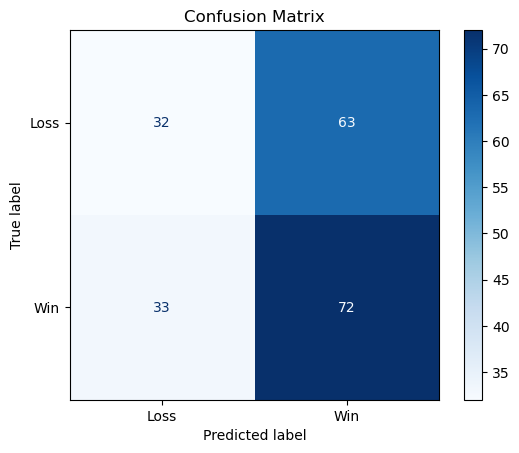

In [29]:
y_true = y_test.numpy()
y_pred = yhat_test_pred.numpy()

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Loss", "Win"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

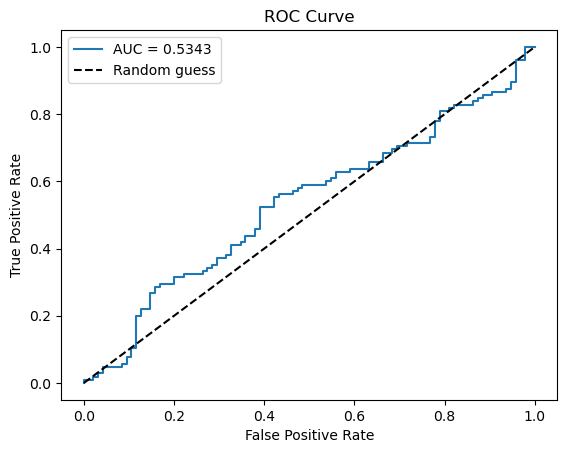

In [30]:
y_prob = yhat_test_prob.numpy()

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc_score = roc_auc_score(y_true, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [31]:
print(classification_report(y_true, y_pred, target_names=["Loss", "Win"]))

              precision    recall  f1-score   support

        Loss       0.49      0.34      0.40        95
         Win       0.53      0.69      0.60       105

    accuracy                           0.52       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.51      0.52      0.51       200



### Model Saving and Loading

In [32]:
# Save
torch.save(model.state_dict(), 'lol_model.pth')

# Load
loaded_model = logistic_regression(input_dim)
loaded_model.load_state_dict(torch.load('lol_model.pth'))
loaded_model.eval()

# Evaluate
with torch.no_grad():
    yhat_loaded = loaded_model(X_test).squeeze()
    yhat_loaded_pred = (yhat_loaded >= 0.5).float()

loaded_acc = yhat_loaded_pred.eq(y_test).float().mean()
print(f"Loaded Model Test Accuracy: {loaded_acc.item():.4f}")

Loaded Model Test Accuracy: 0.5200


C:\Users\upman\AppData\Local\Temp\ipykernel_30584\1993049296.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('lol_model.pth'))


### Hyperparameter Tuning 

In [33]:
learning_rates = [0.01, 0.05, 0.1]
epochs_tune = 100
best_lr = None
best_acc = 0

for lr in learning_rates:
    # Reinitialize
    model_tune = logistic_regression(input_dim)
    optimizer_tune = optim.SGD(model_tune.parameters(), lr=lr)
    
    # Train
    for epoch in range(epochs_tune):
        model_tune.train()
        yhat = model_tune(X_train)
        loss = criterion(yhat, y_train)
        optimizer_tune.zero_grad()
        loss.backward()
        optimizer_tune.step()
    
    # Evaluate
    model_tune.eval()
    with torch.no_grad():
        yhat_test = model_tune(X_test).squeeze()
        yhat_pred = (yhat_test >= 0.5).float()
    
    acc = yhat_pred.eq(y_test).float().mean().item()
    print(f"LR: {lr} → Test Accuracy: {acc:.4f}")
    
    if acc > best_acc:
        best_acc = acc
        best_lr = lr

print(f"\nBest LR: {best_lr} → Accuracy: {best_acc:.4f}")

LR: 0.01 → Test Accuracy: 0.5100
LR: 0.05 → Test Accuracy: 0.4550
LR: 0.1 → Test Accuracy: 0.5050

Best LR: 0.01 → Accuracy: 0.5100
